In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from rdkit import Chem
from rdkit.Chem import Descriptors
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.compose import ColumnTransformer
from rdkit import Chem
from sklearn.linear_model import LinearRegression

In [40]:
df = pd.read_csv(r'C:\Users\mahdi\Downloads\TgSS_enriched_cleaned.csv')
df

,SMILES,Tg,PID,Polymer Class
0,*C*,-54.000000,P010001,Polyolefins
1,*CC(*)C,-3.000000,P010002,Polyolefins
2,*CC(*)CC,-24.100000,P010003,Polyolefins
3,*CC(*)CCC,-37.000000,P010004,Polyolefins
4,*CC(*)C(C)C,60.000000,P010006,Polyolefins
...,...,...,...,...
7279,*CC(F)(F)C1(F)CC(CC(O)(C(F)(F)F)C(F)(F)F)CC1*,98.000000,P522047,Other polymers
7280,*CC(F)(F)C1(F)CC(C(O)(C(F)(F)F)C(F)(F)F)CC1*,118.000000,P522048,Other polymers
7281,*CC(*)(F)C(=O)OCC(Cl)(Cl)Cl,127.000000,P522055,Other polymers
7282,*/C=C/*,332.708838,P014362,Polydienes


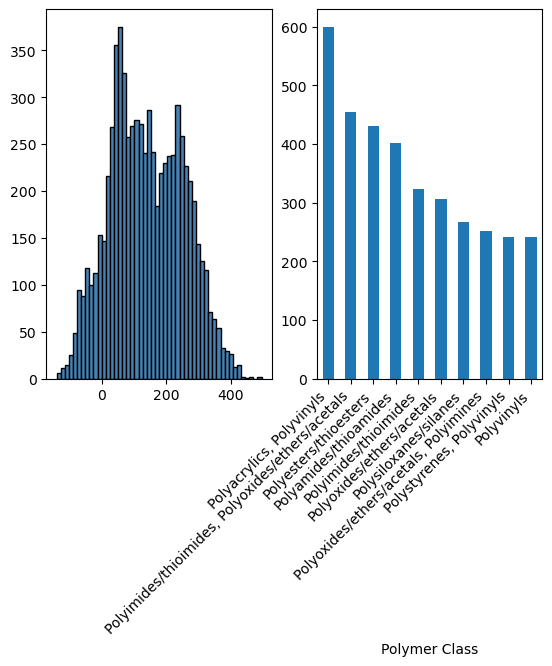

In [41]:
plt.subplot(1,2,1)
plt.hist(df['Tg'], bins = 50, color = 'steelblue', edgecolor = 'black')
plt.subplot(1,2,2)

df['Polymer Class'].value_counts().head(10).plot(kind= 'bar')
plt.xticks(rotation= 45, ha = 'right')

plt.show()

In [42]:
def smiles_to_descriptors(smiles):
    descriptors = {}
    
    clean_smiles = smiles.replace('*', '[H]')
    
    mol = Chem.MolFromSmiles(clean_smiles)
    
    if mol is None:
        return None
    for name, func in Descriptors.descList:
        try:
            descriptors[name] = func(mol)
        except:
            descriptors[name] = None
    return descriptors
    
test =  smiles_to_descriptors('*CC(*)C')
print(len(list(test)))

217


In [9]:
valid_idx = []
descriptors_list = []
for idx, smiles in enumerate(df['SMILES']):
    desc = smiles_to_descriptors(smiles)
    if desc is not None:
        descriptors_list.append(desc)
        valid_idx.append(idx)

    if idx % 1000 == 0:
        print(f'{idx}/{len(df)}')
    

0/7284
1000/7284
2000/7284
3000/7284
4000/7284
5000/7284
6000/7284
7000/7284


In [43]:
desc_df = pd.DataFrame(descriptors_list)
tg_values = df['Tg'].iloc[valid_idx].reset_index(drop=True)
desc_df.shape
print(f"Missing values in descriptors: {desc_df.isnull().sum().sum()}")

Missing values in descriptors: 400


In [44]:
# 1. Replace infinity
desc_df = desc_df.replace([np.inf, -np.inf], np.nan)
desc_df = desc_df.drop(columns=['Ipc'])
# 2. Fill NaN with median
desc_df = desc_df.fillna(desc_df.median())

# 3. Remove constant columns
desc_df = desc_df.drop(columns=[col for col in desc_df.columns if desc_df[col].nunique() <= 1])

# 4. Then define X and y
X = desc_df
y = tg_values

In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [46]:


# Step 7 - Train Random Forest
model = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [47]:
y_pred = model.predict(X_test)
train_r2 = r2_score(y_train, model.predict(X_train))
test_r2  = r2_score(y_test, y_pred)
mae      = mean_absolute_error(y_test, y_pred)
rmse     = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"\nTrain R²: {train_r2:.3f}")
print(f"Test R²:  {test_r2:.3f}")
print(f"Gap:      {train_r2 - test_r2:.3f}")
print(f"MAE:      {mae:.1f}°C")
print(f"RMSE:     {rmse:.1f}°C")


Train R²: 0.974
Test R²:  0.869
Gap:      0.105
MAE:      28.1°C
RMSE:     40.9°C


In [ ]:
# Feature importance
importances = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("Top 10 most important descriptors:")
print(importances.head(10))

# Visualize
plt.figure(figsize=(10,6))
importances.head(15).plot(kind='bar', color='steelblue')
plt.title('Top 15 Most Important Descriptors for Tg Prediction')
plt.xlabel('Descriptor')
plt.ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import cross_val_score

# Test different max_depth values
depths = [5, 10, 15, 20, None]  # None = unlimited

print("Testing max_depth:")
print(f"{'Depth':<10} {'Train R²':<12} {'Test R²':<12} {'Gap':<10}")
print("-" * 45)

for depth in depths:
    rf = RandomForestRegressor(
        n_estimators=100, 
        max_depth=depth, 
        random_state=42
    )
    rf.fit(X_train, y_train)
    train_r2 = r2_score(y_train, rf.predict(X_train))
    test_r2  = r2_score(y_test, rf.predict(X_test))
    depth_label = str(depth) if depth else 'unlimited'
    print(f"{depth_label:<10} {train_r2:<12.3f} {test_r2:<12.3f} {train_r2-test_r2:<10.3f}")

In [40]:
# Test different n_estimators with best depth=15
trees = [10, 50, 100, 200, 500]

print("Testing n_estimators:")
print(f"{'Trees':<10} {'Train R²':<12} {'Test R²':<12} {'Gap':<10}")
print("-" * 45)

for n in trees:
    rf = RandomForestRegressor(
        n_estimators=n,
        max_depth=15,
        random_state=42
    )
    rf.fit(X_train, y_train)
    train_r2 = r2_score(y_train, rf.predict(X_train))
    test_r2  = r2_score(y_test, rf.predict(X_test))
    print(f"{n:<10} {train_r2:<12.3f} {test_r2:<12.3f} {train_r2-test_r2:<10.3f}")

Testing n_estimators:
Trees      Train R²     Test R²      Gap       
---------------------------------------------
10         0.965        0.850        0.115     
50         0.973        0.866        0.106     
100        0.974        0.867        0.107     
200        0.974        0.869        0.105     
500        0.974        0.870        0.104     


In [48]:
# One hot encode polymer class
class_dummies = pd.get_dummies(df['Polymer Class'].iloc[valid_idx].reset_index(drop=True))

# Add to descriptor dataframe
X_new = pd.concat([desc_df, class_dummies], axis=1)

print(f"New feature matrix shape: {X_new.shape}")

New feature matrix shape: (7284, 403)


In [49]:
train_X, test_X, train_y, test_y = train_test_split(X_new, y, test_size = 0.2, random_state=42)
new_model = RandomForestRegressor(n_estimators = 200, max_depth = 15, random_state=42)
new_model.fit(train_X, train_y)
yhat = new_model.predict(test_X)
train_R2 = r2_score(train_y, new_model.predict(train_X))
test_R2 = r2_score(test_y, yhat)
mae = mean_absolute_error(test_y, yhat)
rmse = np.sqrt(mean_squared_error(test_y, yhat))
print(f"Train R²: {train_R2:.3f}")
print(f"Test R²:  {test_R2:.3f}")
print(f"Gap:      {train_R2-test_R2:.3f}")
print(f"MAE:      {mae:.1f}°C")
print(f"RMSE:     {rmse:.1f}°C")

Train R²: 0.974
Test R²:  0.871
Gap:      0.103
MAE:      27.9°C
RMSE:     40.5°C


In [49]:
!pip install xgboost

In [2]:
import sys
!{sys.executable} -m pip install xgboost

In [2]:
from xgboost import XGBRegressor
print("XGBoost ready!")

XGBoost ready!


In [58]:
# WHY we do this step
from xgboost import XGBRegressor

model_xgb = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    random_state=42
)
model_xgb.fit(train_X, train_y)
yhat = model_xgb.predict(test_X)
train_R2 = r2_score(train_y, model_xgb.predict(train_X))
test_R2 = r2_score(test_y, model_xgb.predict(test_X))
mae = mean_absolute_error(test_y, model_xgb.predict(test_X))
rmse = np.sqrt(mean_squared_error(test_y, model_xgb.predict(test_X)))
print(f"Train R²: {train_R2:.3f}")
print(f"Test R²:  {test_R2:.3f}")
print(f"Gap:      {train_R2-test_R2:.3f}")
print(f"MAE:      {mae:.1f}°C")
print(f"RMSE:     {rmse:.1f}°C")

Train R²: 0.979
Test R²:  0.881
Gap:      0.098
MAE:      25.8°C
RMSE:     39.0°C


In [59]:
# Test learning rate impact
learning_rates = [0.01, 0.05, 0.1, 0.3]

print("Testing learning_rate (n_estimators=500, max_depth=6):")
print(f"{'LR':<8} {'Train R²':<12} {'Test R²':<12} {'MAE':<10} {'Gap':<10}")
print("-" * 55)

for lr in learning_rates:
    xgb = XGBRegressor(
        n_estimators=500,
        max_depth=6,
        learning_rate=lr,
        random_state=42
    )
    xgb.fit(X_train, y_train)
    train_r2 = r2_score(y_train, xgb.predict(X_train))
    test_r2  = r2_score(y_test, xgb.predict(X_test))
    mae      = mean_absolute_error(y_test, xgb.predict(X_test))
    print(f"{lr:<8} {train_r2:<12.3f} {test_r2:<12.3f} {mae:<10.1f} {train_r2-test_r2:<10.3f}")

Testing learning_rate (n_estimators=500, max_depth=6):
LR       Train R²     Test R²      MAE        Gap       
-------------------------------------------------------
0.01     0.933        0.870        28.8       0.064     
0.05     0.983        0.877        26.2       0.107     
0.1      0.995        0.879        25.8       0.116     
0.3      0.998        0.865        27.5       0.133     


In [15]:
# Test low learning rate with more trees
from sklearn.model_selection import cross_val_score

configs = [
    (0.01, 500),
    (0.01, 1000),
    (0.01, 2000),
    (0.1,  500),
]

print(f"{'LR':<8} {'Trees':<8} {'Train R²':<12} {'Test R²':<12} {'MAE':<10} {'Gap':<10}")
print("-" * 62)

for lr, n in configs:
    xgb = XGBRegressor(
        n_estimators=n,
        max_depth=6,
        learning_rate=lr,
        random_state=42
    )
    xgb.fit(X_train, y_train)
    train_r2 = r2_score(y_train, xgb.predict(X_train))
    test_r2  = r2_score(y_test, xgb.predict(X_test))
    mae      = mean_absolute_error(y_test, xgb.predict(X_test))
    print(f"{lr:<8} {n:<8} {train_r2:<12.3f} {test_r2:<12.3f} {mae:<10.1f} {train_r2-test_r2:<10.3f}")

LR       Trees    Train R²     Test R²      MAE        Gap       
--------------------------------------------------------------
0.01     500      0.933        0.870        28.8       0.064     
0.01     1000     0.955        0.875        27.4       0.080     
0.01     2000     0.976        0.879        26.3       0.097     
0.1      500      0.995        0.879        25.8       0.116     


In [13]:
# Final XGBoost model
final_xgb = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)
final_xgb.fit(X_train, y_train)

y_pred_xgb = final_xgb.predict(X_test)
train_r2 = r2_score(y_train, final_xgb.predict(X_train))
test_r2  = r2_score(y_test, y_pred_xgb)
mae      = mean_absolute_error(y_test, y_pred_xgb)
rmse     = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

print("=" * 40)
print("   FINAL XGBOOST MODEL RESULTS")
print("=" * 40)
print(f"Train R²: {train_r2:.3f}")
print(f"Test R²:  {test_r2:.3f}")
print(f"Gap:      {train_r2-test_r2:.3f}")
print(f"MAE:      {mae:.1f}°C")
print(f"RMSE:     {rmse:.1f}°C")
print("=" * 40)

# Feature importance
importances_xgb = pd.Series(
    final_xgb.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print("\nTop 10 most important features:")
print(importances_xgb.head(10))

   FINAL XGBOOST MODEL RESULTS
Train R²: 0.995
Test R²:  0.879
Gap:      0.116
MAE:      25.8°C
RMSE:     39.3°C

Top 10 most important features:
RingCount            0.531147
fr_benzene           0.101817
fr_unbrch_alkane     0.051498
NumSaturatedRings    0.027098
FractionCSP3         0.023274
fr_bicyclic          0.022234
fr_ether             0.016340
fr_aniline           0.008551
NumRotatableBonds    0.008137
NHOHCount            0.006964
dtype: float32


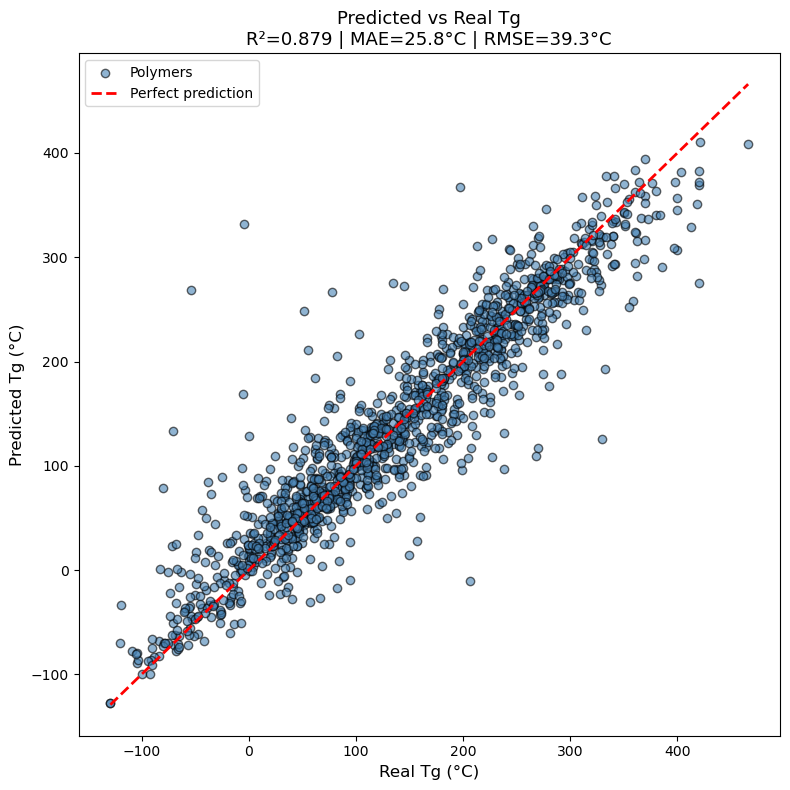

In [25]:
plt.figure(figsize=(8, 8))  # square plot - important for this chart
plt.scatter(y_test, y_pred_xgb, 
            edgecolor='black', 
            alpha=0.6,
            color='steelblue',
            label='Polymers')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 
         'r--', 
         linewidth=2,
         label='Perfect prediction')
plt.xlabel('Real Tg (°C)', fontsize=12)
plt.ylabel('Predicted Tg (°C)', fontsize=12)
plt.title(f'Predicted vs Real Tg\nR²={test_r2:.3f} | MAE={mae:.1f}°C | RMSE={rmse:.1f}°C', 
          fontsize=13)
plt.legend()
plt.tight_layout()
plt.show()

C:\Users\mahdi\AppData\Local\Temp\ipykernel_8024\2786076107.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  error_by_range = test_df.groupby('Tg_Range')['Error'].mean()


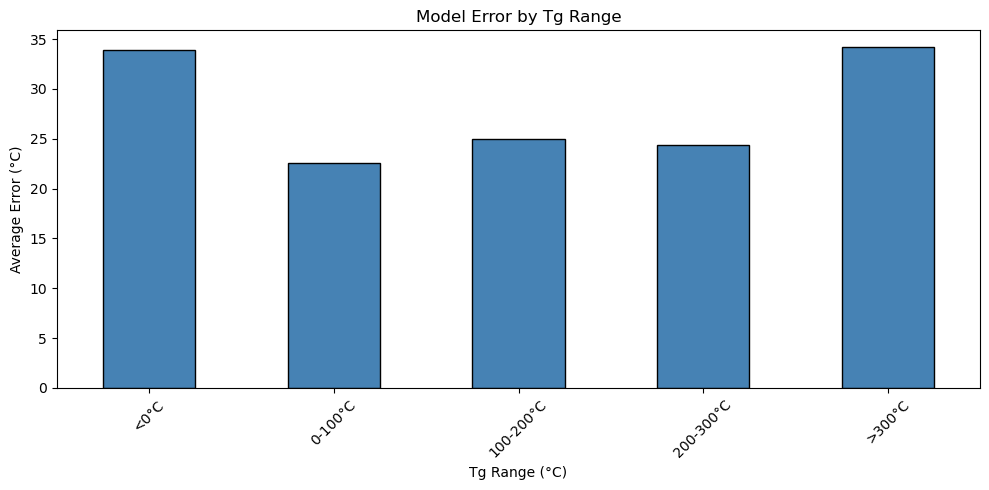

Tg_Range
<0°C         33.924860
0-100°C      22.593919
100-200°C    24.991673
200-300°C    24.388187
>300°C       34.174403
Name: Error, dtype: float64


In [26]:
# Analyze errors by Tg range
test_df = pd.DataFrame({
    'Real_Tg': y_test.values,
    'Predicted_Tg': y_pred_xgb,
    'Error': abs(y_test.values - y_pred_xgb)
})

# Split into Tg ranges
bins = [-150, 0, 100, 200, 300, 500]
labels = ['<0°C', '0-100°C', '100-200°C', '200-300°C', '>300°C']
test_df['Tg_Range'] = pd.cut(test_df['Real_Tg'], bins=bins, labels=labels)

# Average error per range
error_by_range = test_df.groupby('Tg_Range')['Error'].mean()

plt.figure(figsize=(10, 5))
error_by_range.plot(kind='bar', color='steelblue', edgecolor='black')
plt.xlabel('Tg Range (°C)')
plt.ylabel('Average Error (°C)')
plt.title('Model Error by Tg Range')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(error_by_range)

In [31]:
from sklearn.model_selection import KFold, cross_val_score

# 5-fold cross validation on XGBoost
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    final_xgb, 
    X_new, 
    y, 
    cv=kf, 
    scoring='r2',
    verbose=1
)

print(f"CV R² scores: {cv_scores}")
print(f"Average R²:   {cv_scores.mean():.3f}")
print(f"Std deviation:{cv_scores.std():.3f}")
print(f"Range:        {cv_scores.min():.3f} to {cv_scores.max():.3f}")

CV R² scores: [0.88630529 0.88134836 0.86086806 0.89283593 0.89622539]
Average R²:   0.884
Std deviation:0.012
Range:        0.861 to 0.896


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:  1.5min finished


In [34]:
import torch
import torch.nn as nn
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error

# Step 1 - Prepare data
X_array = X_new.values.astype(np.float32)
y_array = y.values.astype(np.float32).reshape(-1, 1)

# Step 2 - Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_array)

# Step 3 - Split
X_train_nn, X_test_nn, y_train_nn, y_test_nn = train_test_split(
    X_scaled, y_array, test_size=0.2, random_state=42
)

# Step 4 - Convert to PyTorch tensors
X_train_t = torch.FloatTensor(X_train_nn)
X_test_t  = torch.FloatTensor(X_test_nn)
y_train_t = torch.FloatTensor(y_train_nn)
y_test_t  = torch.FloatTensor(y_test_nn)

# Step 5 - Define Neural Network
class TgPredictor(nn.Module):
    def __init__(self, input_size):
        super(TgPredictor, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )
    def forward(self, x):
        return self.network(x)

# Step 6 - Initialize model
model_nn = TgPredictor(input_size=X_train_t.shape[1])
optimizer = torch.optim.Adam(model_nn.parameters(), lr=0.001)
criterion = nn.MSELoss()

# Step 7 - Train
epochs = 200
for epoch in range(epochs):
    model_nn.train()
    optimizer.zero_grad()
    predictions = model_nn(X_train_t)
    loss = criterion(predictions, y_train_t)
    loss.backward()
    optimizer.step()
    
    if epoch % 20 == 0:
        model_nn.eval()
        with torch.no_grad():
            test_pred = model_nn(X_test_t)
            test_loss = criterion(test_pred, y_test_t)
        print(f"Epoch {epoch}: Train Loss={loss.item():.1f}, Test Loss={test_loss.item():.1f}")

# Step 8 - Evaluate
model_nn.eval()
with torch.no_grad():
    y_pred_nn = model_nn(X_test_t).numpy()

r2  = r2_score(y_test_nn, y_pred_nn)
mae = mean_absolute_error(y_test_nn, y_pred_nn)
print(f"\nNeural Network Results:")
print(f"Test R²: {r2:.3f}")
print(f"MAE:     {mae:.1f}°C")

Epoch 0: Train Loss=32624.8, Test Loss=31355.2
Epoch 20: Train Loss=26058.9, Test Loss=24527.7
Epoch 40: Train Loss=9651.6, Test Loss=8996.6
Epoch 60: Train Loss=4440.8, Test Loss=4356.9
Epoch 80: Train Loss=3225.4, Test Loss=3348.1
Epoch 100: Train Loss=2854.9, Test Loss=2997.8
Epoch 120: Train Loss=2630.8, Test Loss=2808.6
Epoch 140: Train Loss=2495.3, Test Loss=2672.1
Epoch 160: Train Loss=2362.3, Test Loss=2569.7
Epoch 180: Train Loss=2278.7, Test Loss=2484.9

Neural Network Results:
Test R²: 0.811
MAE:     35.4°C


In [35]:
configs = [
    (0.001, 200),
    (0.001, 500),
    (0.0005, 500),
    (0.0005, 1000),
]

print(f"{'LR':<8} {'Epochs':<8} {'Test R²':<12} {'MAE':<10}")
print("-" * 40)

for lr, epochs in configs:
    # Initialize fresh model
    model_test = TgPredictor(input_size=X_train_t.shape[1])
    optimizer_test = torch.optim.Adam(model_test.parameters(), lr=lr)
    criterion = nn.MSELoss()
    
    # Train
    for epoch in range(epochs):
        model_test.train()
        optimizer_test.zero_grad()
        pred = model_test(X_train_t)
        loss = criterion(pred, y_train_t)
        loss.backward()
        optimizer_test.step()
    
    # Evaluate
    model_test.eval()
    with torch.no_grad():
        y_pred = model_test(X_test_t).numpy()
    
    r2  = r2_score(y_test_nn, y_pred)
    mae = mean_absolute_error(y_test_nn, y_pred)
    print(f"{lr:<8} {epochs:<8} {r2:<12.3f} {mae:<10.1f}")

LR       Epochs   Test R²      MAE       
----------------------------------------
0.001    200      0.812        35.2      
0.001    500      0.725        30.5      
0.0005   500      0.832        32.9      
0.0005   1000     0.584        30.5      


In [36]:
# Add Early Stopping to training loop
model_nn = TgPredictor(input_size=X_train_t.shape[1])
optimizer = torch.optim.Adam(model_nn.parameters(), lr=0.0005)
criterion = nn.MSELoss()

# Early stopping parameters
best_test_loss = float('inf')
patience = 20  # stop if no improvement for 20 epochs
counter = 0
best_model_state = None

for epoch in range(1000):
    # Train
    model_nn.train()
    optimizer.zero_grad()
    pred = model_nn(X_train_t)
    loss = criterion(pred, y_train_t)
    loss.backward()
    optimizer.step()
    
    # Evaluate
    model_nn.eval()
    with torch.no_grad():
        test_pred = model_nn(X_test_t)
        test_loss = criterion(test_pred, y_test_t)
    
    # Early stopping check
    if test_loss < best_test_loss:
        best_test_loss = test_loss
        counter = 0
        best_model_state = model_nn.state_dict().copy()
    else:
        counter += 1
        if counter >= patience:
            print(f"Early stopping at epoch {epoch}")
            break
    
    if epoch % 20 == 0:
        print(f"Epoch {epoch}: Train={loss.item():.1f}, Test={test_loss.item():.1f}")

# Load best model
model_nn.load_state_dict(best_model_state)

# Evaluate
model_nn.eval()
with torch.no_grad():
    y_pred_nn = model_nn(X_test_t).numpy()

r2  = r2_score(y_test_nn, y_pred_nn)
mae = mean_absolute_error(y_test_nn, y_pred_nn)
print(f"\nNeural Network + Early Stopping:")
print(f"Test R²: {r2:.3f}")
print(f"MAE:     {mae:.1f}°C")

Epoch 0: Train=32660.9, Test=31399.0
Epoch 20: Train=31760.5, Test=30490.6
Epoch 40: Train=24381.2, Test=23334.2
Epoch 60: Train=10908.2, Test=10914.4
Epoch 80: Train=6948.4, Test=7237.4
Epoch 100: Train=4594.6, Test=4575.1
Epoch 120: Train=3514.4, Test=3616.6
Epoch 140: Train=3078.3, Test=3250.3
Epoch 160: Train=2897.0, Test=3044.9
Epoch 180: Train=2754.2, Test=2905.4
Epoch 200: Train=2615.7, Test=2795.7
Epoch 220: Train=2512.4, Test=2702.5
Epoch 240: Train=2452.0, Test=2627.1
Epoch 260: Train=2355.6, Test=2558.5
Epoch 280: Train=2251.0, Test=2497.4
Epoch 300: Train=2217.6, Test=2444.6
Epoch 320: Train=2174.1, Test=2402.0
Epoch 340: Train=2111.5, Test=2361.3
Epoch 360: Train=2079.5, Test=2325.3
Epoch 380: Train=2062.2, Test=2300.7
Epoch 400: Train=2003.1, Test=2265.5
Epoch 420: Train=1932.3, Test=2233.2
Epoch 440: Train=1944.1, Test=2208.9
Epoch 460: Train=1894.9, Test=2181.1
Epoch 480: Train=1882.6, Test=2145.1
Epoch 500: Train=1843.6, Test=2124.4
Epoch 520: Train=1796.2, Test=2096.4

In [53]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# Define X and y
X = desc_df
y = tg_values

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Retrain final Random Forest
final_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    random_state=42
)
final_model.fit(X_train, y_train)

# Verify
print(f"Model trained on: {final_model.n_features_in_} features")
print(f"X_test shape: {X_test.shape}")

Model trained on: 205 features
X_test shape: (1457, 205)


In [54]:
# Get predictions from every individual tree
tree_predictions = np.array([
    tree.predict(X_test) 
    for tree in final_model.estimators_
])

# tree_predictions shape: (200 trees, 1457 test polymers)
print(f"Shape: {tree_predictions.shape}")

# Mean prediction (same as model.predict())
mean_pred = tree_predictions.mean(axis=0)

# Uncertainty = std deviation across trees
uncertainty = tree_predictions.std(axis=0)

print(f"\nExample predictions with uncertainty:")
for i in range(5):
    print(f"Polymer {i}: Tg = {mean_pred[i]:.1f} ± {uncertainty[i]:.1f}°C")

C:\Users\mahdi\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
C:\Users\mahdi\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
C:\Users\mahdi\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
C:\Users\mahdi\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
C:\Users\mahdi\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
C:\Users\mahdi\anaconda3\Lib\site-packages\sklearn\utils\validati

Shape: (200, 1457)

Example predictions with uncertainty:
Polymer 0: Tg = 34.2 ± 86.4°C
Polymer 1: Tg = 211.6 ± 38.4°C
Polymer 2: Tg = 35.0 ± 31.6°C
Polymer 3: Tg = 211.6 ± 31.3°C
Polymer 4: Tg = 89.6 ± 52.4°C


C:\Users\mahdi\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
C:\Users\mahdi\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
C:\Users\mahdi\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
C:\Users\mahdi\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
C:\Users\mahdi\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
C:\Users\mahdi\anaconda3\Lib\site-packages\sklearn\utils\validati

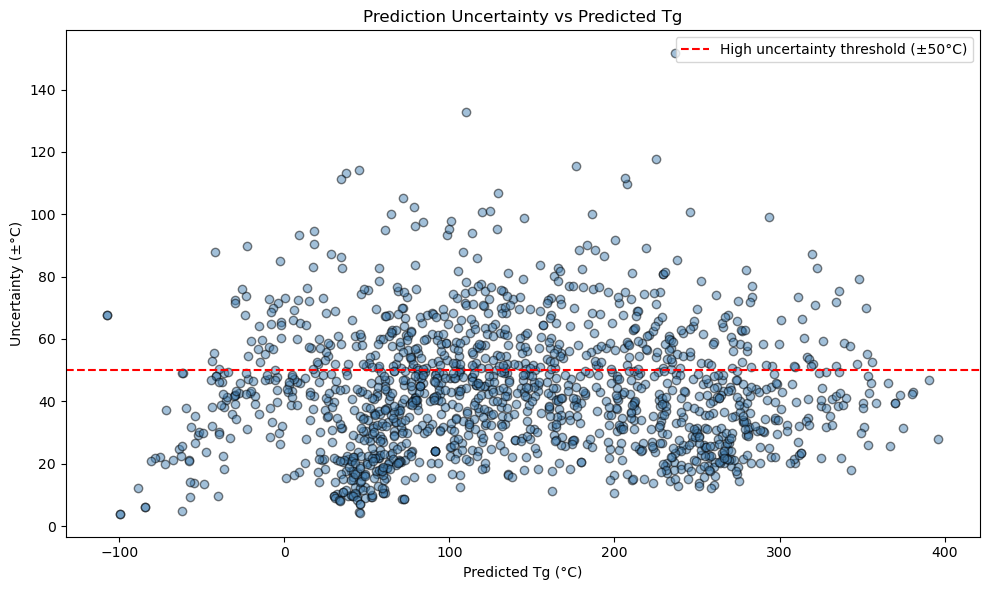

Average uncertainty: ±43.1°C
Max uncertainty:     ±151.6°C
Min uncertainty:     ±4.0°C
Highly uncertain predictions (>50°C): 470 out of 1457


In [55]:
# Plot prediction vs uncertainty
plt.figure(figsize=(10, 6))
plt.scatter(mean_pred, uncertainty, 
            alpha=0.5, 
            color='steelblue',
            edgecolor='black')
plt.xlabel('Predicted Tg (°C)')
plt.ylabel('Uncertainty (±°C)')
plt.title('Prediction Uncertainty vs Predicted Tg')
plt.axhline(y=50, color='red', linestyle='--', label='High uncertainty threshold (±50°C)')
plt.legend()
plt.tight_layout()
plt.show()

# Summary statistics
print(f"Average uncertainty: ±{uncertainty.mean():.1f}°C")
print(f"Max uncertainty:     ±{uncertainty.max():.1f}°C")
print(f"Min uncertainty:     ±{uncertainty.min():.1f}°C")
print(f"Highly uncertain predictions (>50°C): {(uncertainty > 50).sum()} out of {len(uncertainty)}")

In [56]:
# Trustworthy predictions
certain = uncertainty < 30
print(f"High confidence predictions: {certain.sum()} polymers")
print(f"Average MAE for certain predictions: {abs(mean_pred[certain] - y_test.values[certain]).mean():.1f}°C")

# Untrustworthy predictions  
uncertain_mask = uncertainty > 50
print(f"\nLow confidence predictions: {uncertain_mask.sum()} polymers")
print(f"Average MAE for uncertain predictions: {abs(mean_pred[uncertain_mask] - y_test.values[uncertain_mask]).mean():.1f}°C")

High confidence predictions: 404 polymers
Average MAE for certain predictions: 14.5°C

Low confidence predictions: 470 polymers
Average MAE for uncertain predictions: 43.6°C
